In [22]:
#to get the dataset path
import os

print(os.listdir("/kaggle/input"))
dataset_path = "/kaggle/input/datasets"
print(os.listdir(dataset_path))

['datasets']
['hasyimabdillah']


In [23]:
#To get the folder details 
for root, dirs, files in os.walk(dataset_path):
    print("Root:", root)
    print("Folders:", dirs[:10])
    print("Files:", files[:5])
    break

Root: /kaggle/input/datasets
Folders: ['hasyimabdillah']
Files: []


In [24]:
#To get the images folder name
print(os.listdir("/kaggle/input/datasets/hasyimabdillah"))

['workoutexercises-images']


In [25]:
for root, dirs, files in os.walk("/kaggle/input/datasets/hasyimabdillah"):
    print("Root:", root)
    print("Folders:", dirs[:10])
    print("Files:", files[:5])
    print("-" * 50)
    
    if len(dirs) > 0:
        break

Root: /kaggle/input/datasets/hasyimabdillah
Folders: ['workoutexercises-images']
Files: []
--------------------------------------------------


In [26]:
DATASET_PATH = "/kaggle/input/datasets/hasyimabdillah/workoutexercises-images"

print(os.listdir(DATASET_PATH))

['t bar row', 'pull up', 'hammer curl', 'decline bench press', 'tricep pushdown', 'chest fly machine', 'lateral raises', 'squat', 'bench press', 'deadlift', 'leg raises', 'russian twist', 'barbell biceps curl', 'hip thrust', 'lat pulldown', 'plank', 'incline bench press', 'tricep dips', 'leg extension', 'romanian deadlift', 'shoulder press', 'push up']


In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix

In [29]:
#To know the version of tensorflow and set GPU
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [31]:
#Basic settings: all images will be resized to 224×224, 32 images will be processed at one time, and DATASET_PATH is where Kaggle stores the dataset
DATASET_PATH = "/kaggle/input/datasets/hasyimabdillah/workoutexercises-images"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [32]:
#Number of classes and to get class names
class_names = sorted([
    folder for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, folder))
])

print("Number of classes:", len(class_names))
print("Classes:", class_names)

Number of classes: 22
Classes: ['barbell biceps curl', 'bench press', 'chest fly machine', 'deadlift', 'decline bench press', 'hammer curl', 'hip thrust', 'incline bench press', 'lat pulldown', 'lateral raises', 'leg extension', 'leg raises', 'plank', 'pull up', 'push up', 'romanian deadlift', 'russian twist', 'shoulder press', 'squat', 't bar row', 'tricep dips', 'tricep pushdown']


In [33]:
class_distribution = {}

for class_name in class_names:
    class_path = os.path.join(DATASET_PATH, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    class_distribution[class_name] = len(image_files)

class_distribution_df = pd.DataFrame(
    list(class_distribution.items()),
    columns=["Class", "Number of Images"]
)

print("Total Images:", class_distribution_df["Number of Images"].sum())
class_distribution_df

Total Images: 13853


,Class,Number of Images
0,barbell biceps curl,705
1,bench press,625
2,chest fly machine,527
3,deadlift,530
4,decline bench press,514
5,hammer curl,546
6,hip thrust,557
7,incline bench press,729
8,lat pulldown,646
9,lateral raises,843


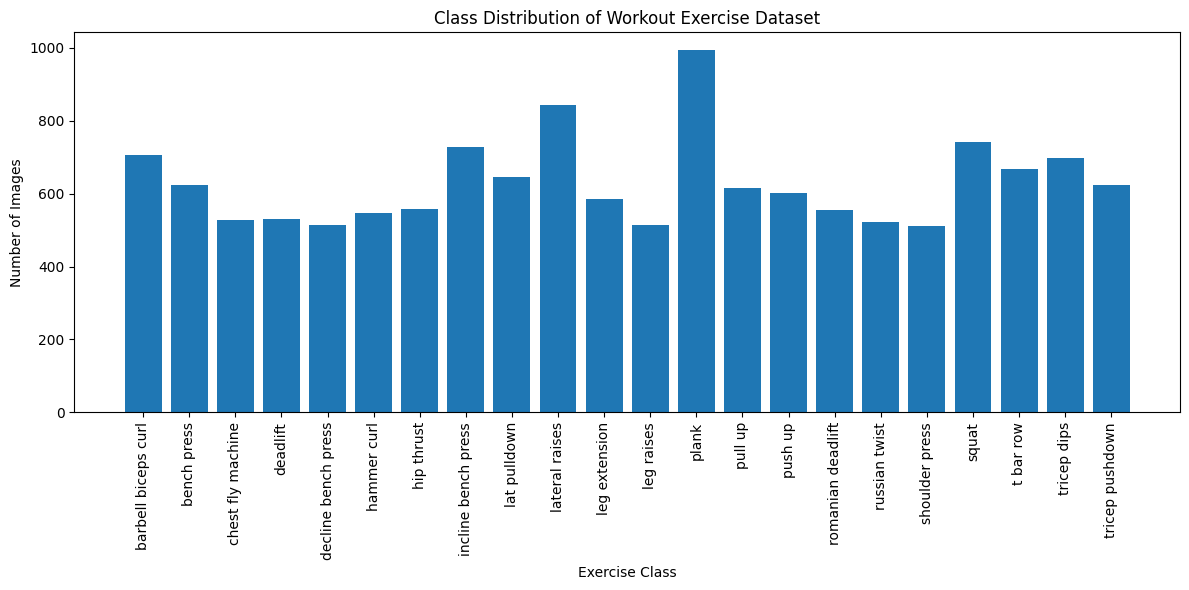

In [34]:
#Class Distribution of Workout Exercise Dataset
plt.figure(figsize=(12, 6))
plt.bar(
    class_distribution_df["Class"],
    class_distribution_df["Number of Images"]
)

plt.xticks(rotation=90)
plt.title("Class Distribution of Workout Exercise Dataset")
plt.xlabel("Exercise Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig("class_distribution.pdf")
plt.show()

In [35]:
#Load training and validation data
train_ds = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.3,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

temp_ds = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 13853 files belonging to 22 classes.
Using 9698 files for training.


I0000 00:00:1780746366.268954      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780746366.275055      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 13853 files belonging to 22 classes.
Using 4155 files for validation.


In [36]:
val_batches = tf.data.experimental.cardinality(temp_ds)

test_ds = temp_ds.take(val_batches // 2)
val_ds = temp_ds.skip(val_batches // 2)

class_names = [
    "barbell biceps curl",
    "bench press",
    "chest fly machine",
    "deadlift",
    "decline bench press",
    "hammer curl",
    "hip thrust",
    "incline bench press",
    "lat pulldown",
    "lateral raises",
    "leg extension",
    "leg raises",
    "plank",
    "pull up",
    "push up",
    "romanian deadlift",
    "russian twist",
    "shoulder press",
    "squat",
    "t bar row",
    "tricep dips",
    "tricep pushdown"
]

num_classes = len(class_names)

import json

with open("/kaggle/working/class_names.json", "w") as f:
    json.dump(class_names, f)

print("class_names.json saved")

class_names.json saved


In [37]:
#Data Augmentation: this creates new variations of images so the model does not simply memorize training images.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

In [38]:
#Improve loading speed: this makes training faster by preparing the next batch while the model is training.
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

In [39]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [40]:
#Custom CNN model
custom_cnn = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

In [41]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

#Compile model
custom_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

#Train custom CNN
history_cnn = custom_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)


Epoch 1/20


I0000 00:00:1780746520.098698     479 cuda_dnn.cc:529] Loaded cuDNN version 91002


304/304 ━━━━━━━━━━━━━━━━━━━━ 59s 84ms/step - accuracy: 0.2168 - loss: 2.6895 - val_accuracy: 0.5176 - val_loss: 1.6956
Epoch 2/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.4895 - loss: 1.7572 - val_accuracy: 0.7595 - val_loss: 0.9699
Epoch 3/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step - accuracy: 0.6524 - loss: 1.2194 - val_accuracy: 0.8458 - val_loss: 0.6524
Epoch 4/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.7220 - loss: 0.9758 - val_accuracy: 0.9007 - val_loss: 0.4389
Epoch 5/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.7679 - loss: 0.7964 - val_accuracy: 0.9214 - val_loss: 0.3715
Epoch 6/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - accuracy: 0.8043 - loss: 0.6839 - val_accuracy: 0.9258 - val_loss: 0.3364
Epoch 7/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.8294 - loss: 0.5925 - val_accuracy: 0.9383 - val_loss: 0.3032
Epoch 8/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.8433 - loss: 0.5349 - val_accurac

In [42]:
# Build Transfer learning model: MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

mobilenet_base = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

mobilenet_base.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)
x = mobilenet_base(x, training=False)

last_conv_output = mobilenet_base.get_layer("Conv_1").output

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

mobilenet_model = tf.keras.Model(inputs, outputs)

#Compile and train MobileNetV2
mobilenet_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_mobilenet = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - accuracy: 0.5829 - loss: 1.4691 - val_accuracy: 0.7913 - val_loss: 0.7507
Epoch 2/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 19s 63ms/step - accuracy: 0.8284 - loss: 0.6153 - val_accuracy: 0.8545 - val_loss: 0.5128
Epoch 3/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - accuracy: 0.8750 - loss: 0.4451 - val_accuracy: 0.8761 - val_loss: 0.4220
Epoch 4/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.8960 - loss: 0.3666 - val_accuracy: 0.8906 - val_loss: 0.3618
Epoch 5/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.9142 - loss: 0.3141 - val_accuracy: 0.9166 - val_loss: 0.3139
Epoch 6/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - accuracy: 0.9207 - loss: 0.2849 - val_accuracy: 0.9046 - val_loss: 0.3151
Epoch 7/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - accuracy: 0.9284 - loss: 0.2532 - val_accuracy: 0.9190 - val_loss: 0.2756
Epoch 8/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 1

In [43]:
from tensorflow.keras.applications.resnet50 import (
    ResNet50,
    preprocess_input
)

resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224,3)
)

resnet_base.trainable = False

resnet_model = models.Sequential([
    layers.Input(shape=(224, 224,3)),
    
    data_augmentation,

    layers.Lambda(preprocess_input),

    resnet_base,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(
        num_classes,
        activation="softmax"
    )
])

resnet_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_resnet = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 59s 170ms/step - accuracy: 0.6755 - loss: 1.1586 - val_accuracy: 0.9108 - val_loss: 0.3638
Epoch 2/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 47s 155ms/step - accuracy: 0.8945 - loss: 0.3953 - val_accuracy: 0.9484 - val_loss: 0.2203
Epoch 3/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 48s 157ms/step - accuracy: 0.9305 - loss: 0.2655 - val_accuracy: 0.9557 - val_loss: 0.1764
Epoch 4/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 48s 156ms/step - accuracy: 0.9445 - loss: 0.2070 - val_accuracy: 0.9590 - val_loss: 0.1551
Epoch 5/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 48s 157ms/step - accuracy: 0.9510 - loss: 0.1742 - val_accuracy: 0.9682 - val_loss: 0.1353
Epoch 6/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 48s 157ms/step - accuracy: 0.9601 - loss: 0.1485 - val_accuracy: 0.9677 - val_loss: 0.1200
Epoch 7/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 48s 157ms/step - accuracy: 0.9626 - loss: 0.1297 - val_accuracy: 0.9696 - val_loss: 0.1238
Epoch 8/10
304/304 ━━━━━━━━━━━━━

In [45]:
#Plot accuracy and loss curves
def plot_curves(history, model_name):
    plt.figure()
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(model_name + " Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.savefig(model_name + "_accuracy_curve.pdf")
    plt.show()

    plt.figure()
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(model_name + " Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.savefig(model_name + "_loss_curve.pdf")
    plt.show()

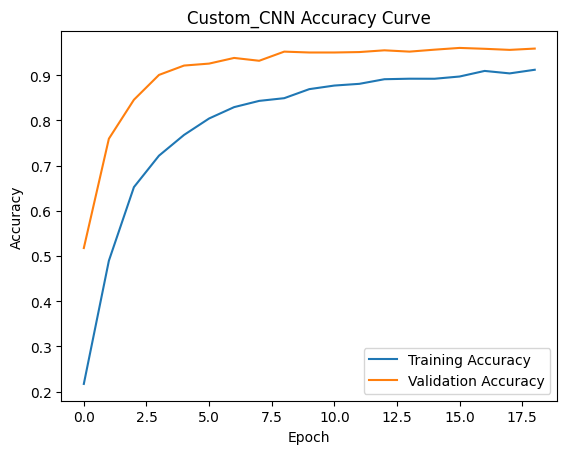

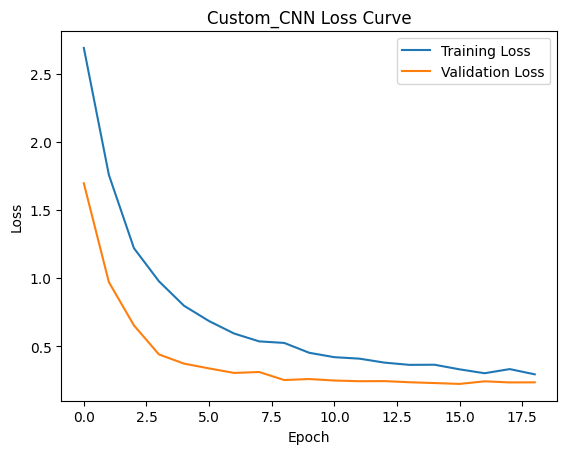

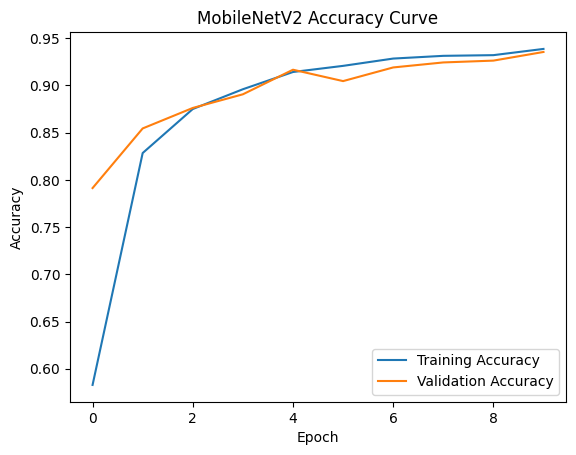

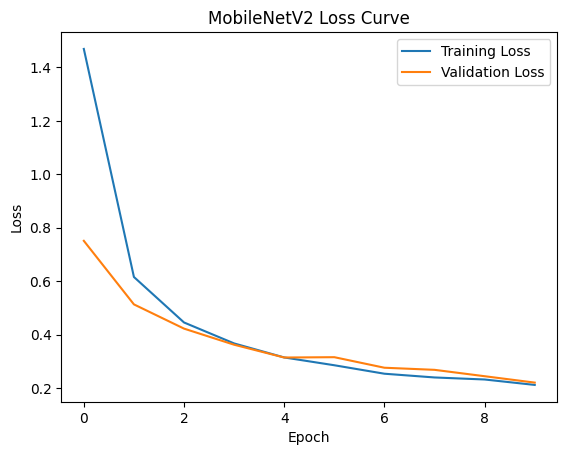

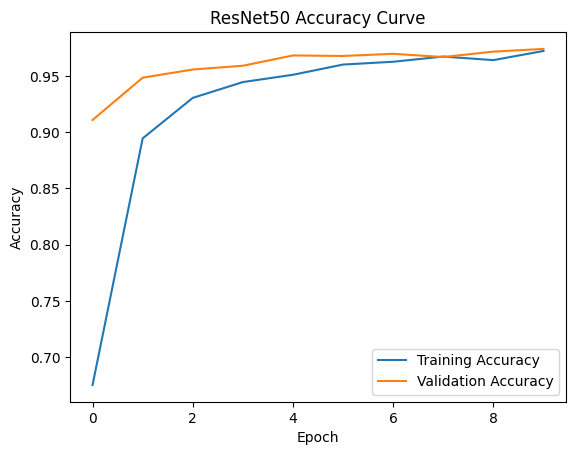

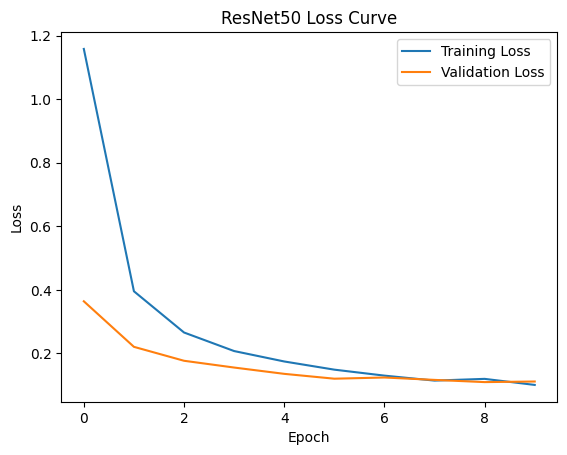

In [46]:
plot_curves(history_cnn, "Custom_CNN")
plot_curves(history_mobilenet, "MobileNetV2")
plot_curves(history_resnet, "ResNet50")

In [48]:
#Classification report and confusion matrix
def evaluate_model(model, model_name):
    y_true = []
    y_pred = []

    for images, labels in test_ds:
        predictions = model.predict(images)
        predicted_classes = np.argmax(predictions, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted_classes)

    print("Classification Report for", model_name)
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(12, 10))
    plt.imshow(cm)
    plt.title("Confusion Matrix - " + model_name)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.colorbar()
    plt.savefig(model_name + "_confusion_matrix.pdf")
    plt.show()

    test_loss, test_accuracy = model.evaluate(test_ds)
    
    return test_accuracy

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━

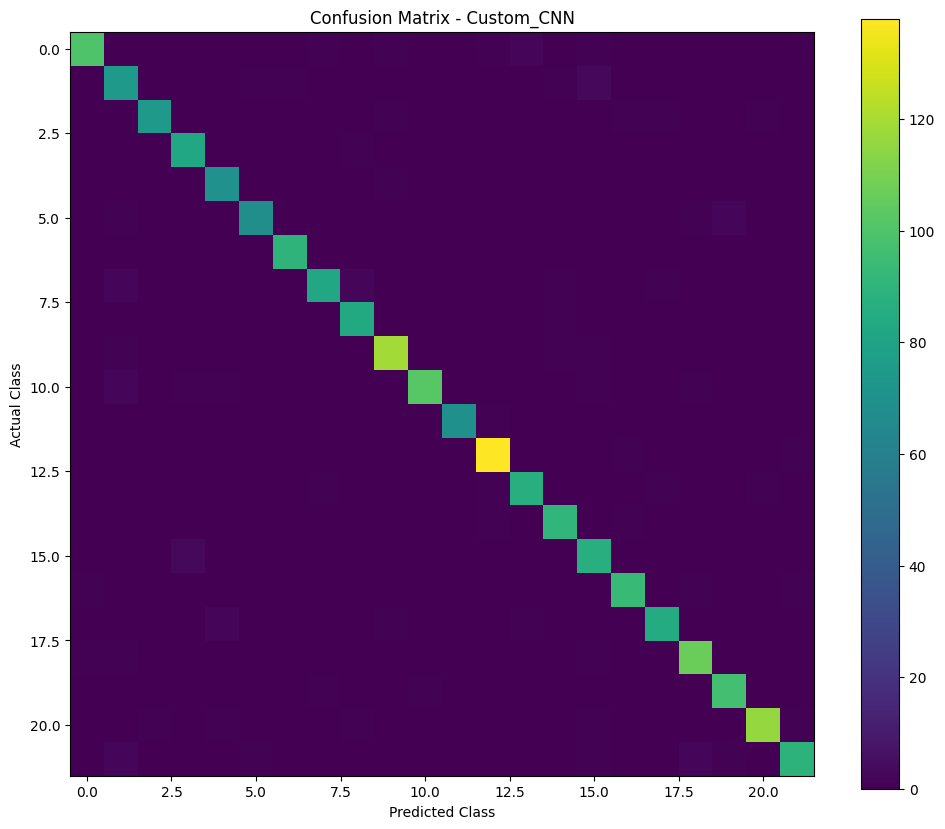

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9644 - loss: 0.2059
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━

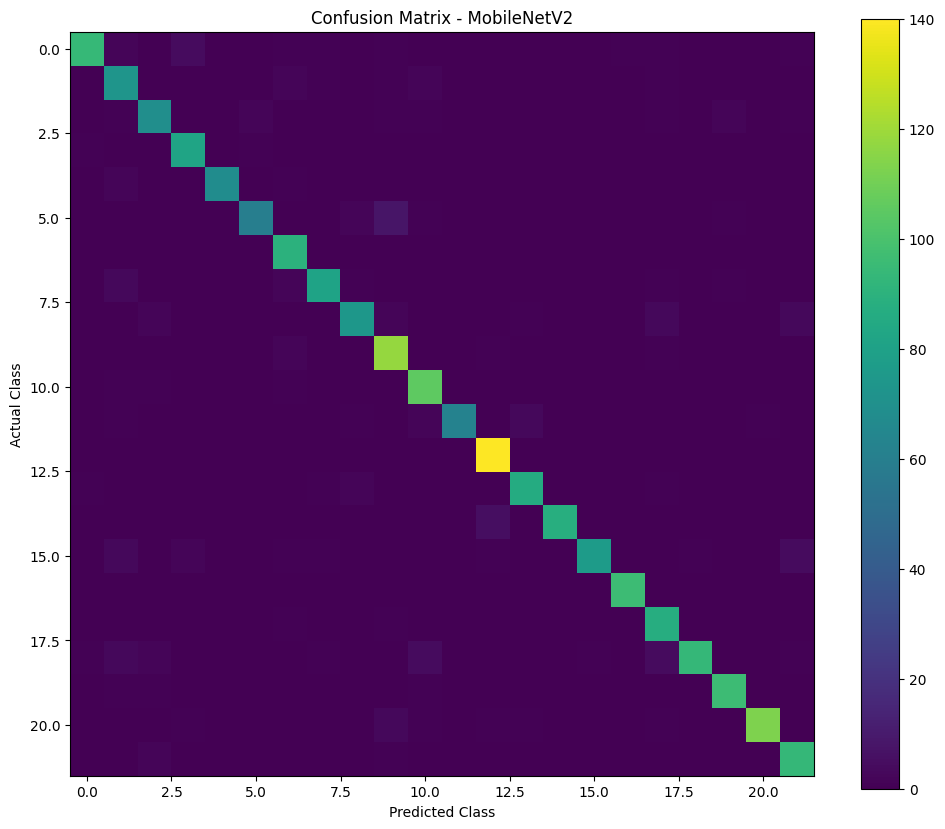

65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9351 - loss: 0.2149
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166m

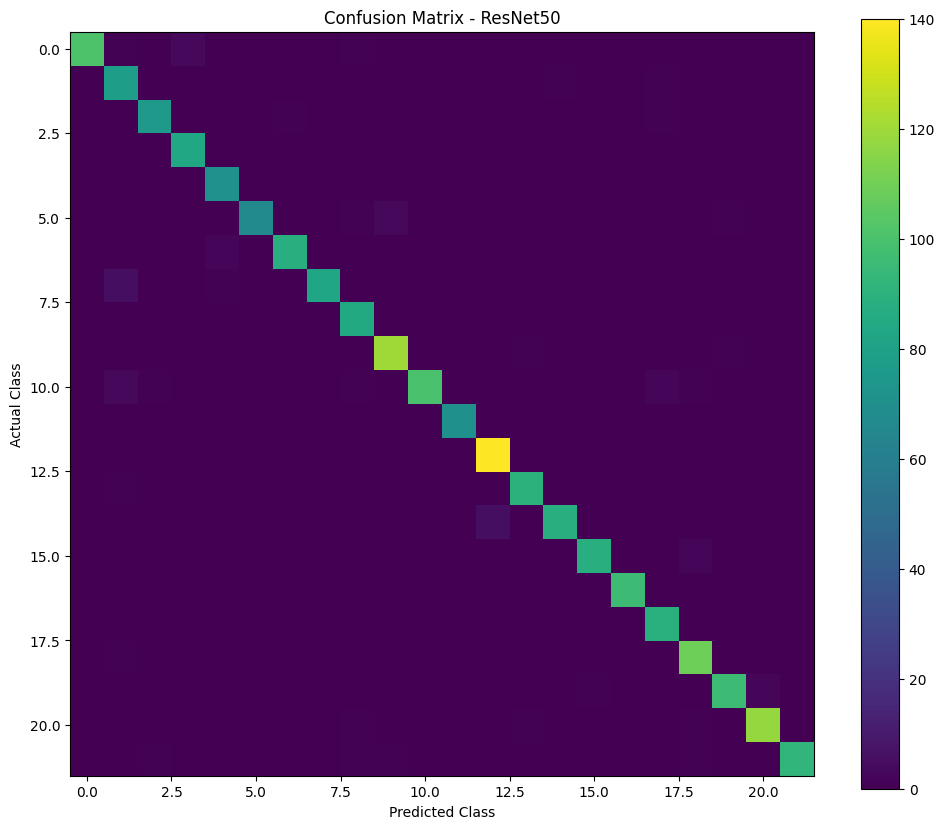

65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 128ms/step - accuracy: 0.9755 - loss: 0.1078


In [49]:
cnn_accuracy = evaluate_model(custom_cnn, "Custom_CNN")
mobilenet_accuracy = evaluate_model(mobilenet_model, "MobileNetV2")
resnet_accuracy = evaluate_model(resnet_model, "ResNet50")


In [60]:
#Comparison table
model_comparison = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2", "ResNet50"],
    "Test Accuracy": [cnn_accuracy, mobilenet_accuracy, resnet_accuracy]
})

model_comparison

#saves the trained model
model_comparison.to_csv("model_comparison.csv", index=False)
best_model = mobilenet_model
best_model.save("exercise_posture_best_model.h5")
custom_cnn.save("exercise_posture_custom_cnn.keras")

In [51]:
mobilenet_model.summary()
for images, labels in test_ds.take(1):
    img = images[0]
    label = labels[0]
    break

img_array = tf.expand_dims(img, axis=0)

_ = mobilenet_model(img_array)


last_conv_layer = mobilenet_base.get_layer("Conv_1")

grad_model = tf.keras.Model(
    inputs=mobilenet_model.input,
    outputs=[
        last_conv_layer.output,
        mobilenet_model.output
    ]
)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 22)             │        28,182 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,342,532 (8.94 MB)

 Trainable params: 28,182 (110.09 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 56,366 (220.18 KB)

In [52]:
#Save best model
best_accuracy = max(cnn_accuracy, mobilenet_accuracy, resnet_accuracy)

if best_accuracy == cnn_accuracy:
    best_model = custom_cnn
    best_model_name = "Custom_CNN"
elif best_accuracy == mobilenet_accuracy:
    best_model = mobilenet_model
    best_model_name = "MobileNetV2"
else:
    best_model = resnet_model
    best_model_name = "ResNet50"

print("Best Model:", best_model_name)
print("Best Test Accuracy:", best_accuracy)

Best Model: ResNet50
Best Test Accuracy: 0.9754807949066162


In [53]:
#Save model comparison table
model_comparison = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2", "ResNet50"],
    "Test Accuracy": [cnn_accuracy, mobilenet_accuracy, resnet_accuracy]
})

model_comparison.to_csv("model_comparison.csv", index=False)
model_comparison


,Model,Test Accuracy
0,Custom CNN,0.964423
1,MobileNetV2,0.935096
2,ResNet50,0.975481


In [54]:
last_conv_layer_name = "conv5_block3_out"

In [55]:
# Get one image
for images, labels in test_ds.take(1):
    img = images[0]
    label = labels[0]
    break

img_array = tf.expand_dims(img, axis=0)

# Create model that outputs last convolution feature map
feature_extractor = tf.keras.Model(
    inputs=mobilenet_base.input,
    outputs=mobilenet_base.get_layer("Conv_1").output
)
# Get classifier layers from your trained MobileNetV2 model
gap_layer = mobilenet_model.layers[-3]
dropout_layer = mobilenet_model.layers[-2]
dense_layer = mobilenet_model.layers[-1]

In [56]:
#Grad-CAM explanation, creates a heatmap showing important image areas used by the model.
with tf.GradientTape() as tape:
    preprocessed_img = preprocess_input(img_array)

    conv_outputs = feature_extractor(preprocessed_img)

    tape.watch(conv_outputs)

    x = gap_layer(conv_outputs)
    x = dropout_layer(x, training=False)
    predictions = dense_layer(x)

    predicted_class = tf.argmax(predictions[0])
    class_score = predictions[:, predicted_class]

grads = tape.gradient(class_score, conv_outputs)

pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

heatmap = tf.maximum(heatmap, 0)

heatmap = heatmap / tf.reduce_max(heatmap)

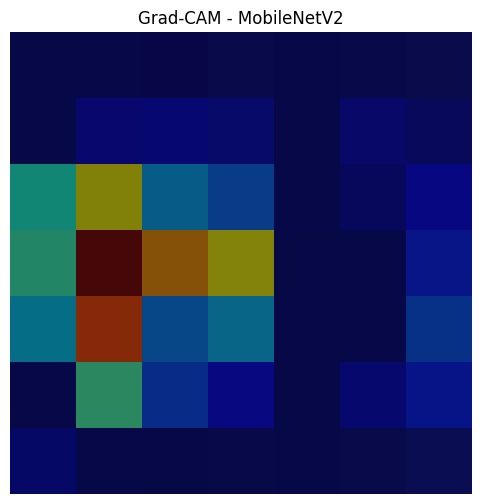

In [57]:
plt.figure(figsize=(6, 6))
plt.imshow(np.array(img).astype("uint8"))
plt.imshow(heatmap.numpy(), cmap="jet", alpha=0.5)
plt.title("Grad-CAM - MobileNetV2")
plt.axis("off")
plt.savefig("gradcam_mobilenetv2.pdf")
plt.show()

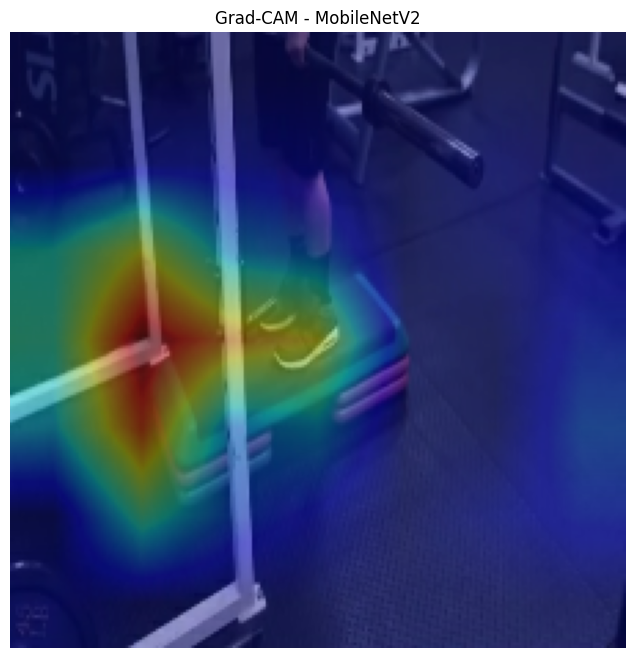

In [58]:
plt.figure(figsize=(8, 8))

plt.imshow(np.array(img).astype("uint8"))

resized_heatmap = tf.image.resize(
    heatmap[..., tf.newaxis],
    (224, 224)
).numpy().squeeze()

plt.imshow(
    resized_heatmap,
    cmap="jet",
    alpha=0.4
)

plt.title("Grad-CAM - MobileNetV2")
plt.axis("off")
plt.savefig("gradcam_mobilenetv2_overlay.pdf")
plt.show()

In [63]:
import zipfile
import os

files_to_zip = [
    "exercise_posture_best_model.h5",
    "model_comparison.csv",
    "class_names.json",
    "class_distribution.pdf",
    "Custom_CNN_accuracy_curve.pdf",
    "Custom_CNN_loss_curve.pdf",
    "Custom_CNN_confusion_matrix.pdf",
    "MobileNetV2_accuracy_curve.pdf",
    "MobileNetV2_loss_curve.pdf",
    "MobileNetV2_confusion_matrix.pdf",
    "ResNet50_accuracy_curve.pdf",
    "ResNet50_loss_curve.pdf",
    "ResNet50_confusion_matrix.pdf",
    "gradcam_mobilenetv2_overlay.png"
]

zip_path = "/kaggle/working/selected_outputs.zip"

with zipfile.ZipFile(zip_path, "w") as zipf:
    for file in files_to_zip:
        file_path = f"/kaggle/working/{file}"
        if os.path.exists(file_path):
            zipf.write(file_path, arcname=file)

print("Selected outputs ZIP created:", zip_path)

Selected outputs ZIP created: /kaggle/working/selected_outputs.zip
